🔹 Bloc 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Device : GPU si disponible, sinon CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ Device          : {device}")
if torch.cuda.is_available():
    print(f"✅ GPU             : {torch.cuda.get_device_name(0)}")

✅ PyTorch version : 2.7.1+cu118
✅ Device          : cuda
✅ GPU             : NVIDIA GeForce GTX 1650 Ti


🔹 Bloc 2 — Load Data

In [2]:
train_df = pd.read_csv("training.csv")
val_df   = pd.read_csv("validation.csv")
test_df  = pd.read_csv("test.csv")

emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
num_classes   = 6

print(f"Train : {len(train_df)} exemples")
print(f"Val   : {len(val_df)} exemples")
print(f"Test  : {len(test_df)} exemples")
print(f"\nDistribution train :")
print(train_df['label'].value_counts().sort_index())

Train : 16000 exemples
Val   : 2000 exemples
Test  : 2000 exemples

Distribution train :
label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64


🔹 Bloc 3 — Class Weights

In [3]:
classes = np.unique(train_df['label'].values)
weights = compute_class_weight('balanced',
                                classes=classes,
                                y=train_df['label'].values)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print("Class weights :")
for i, (name, w) in enumerate(zip(emotion_names, weights)):
    print(f"  {name:10s} → {w:.4f}")

Class weights :
  sadness    → 0.5715
  joy        → 0.4973
  love       → 2.0450
  anger      → 1.2351
  fear       → 1.3767
  surprise   → 4.6620


🔹 Bloc 4 — Tokenizer

In [4]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer chargé : {MODEL_NAME}")

✅ Tokenizer chargé : distilbert-base-uncased


🔹 Bloc 5 — Dataset PyTorch

In [5]:
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Créer les datasets
BATCH_SIZE = 16

train_dataset = EmotionDataset(train_df['text'].values,
                                train_df['label'].values,
                                tokenizer, MAX_LEN)
val_dataset   = EmotionDataset(val_df['text'].values,
                                val_df['label'].values,
                                tokenizer, MAX_LEN)
test_dataset  = EmotionDataset(test_df['text'].values,
                                test_df['label'].values,
                                tokenizer, MAX_LEN)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"✅ Datasets prêts")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ Datasets prêts
   Train batches : 1000
   Val batches   : 125
   Test batches  : 125


🔹 Bloc 6 — Modèle

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes
)
model = model.to(device)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Modèle chargé : {MODEL_NAME}")
print(f"   Total params     : {total_params:,}")
print(f"   Trainable params : {trainable:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle chargé : distilbert-base-uncased
   Total params     : 66,958,086
   Trainable params : 66,958,086


🔹 Bloc 7 — Optimizer & Scheduler

In [7]:
EPOCHS       = 4
LR           = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Loss avec class weights
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print(f"✅ Optimizer   : AdamW (lr={LR})")
print(f"✅ Total steps : {total_steps}")
print(f"✅ Warmup steps: {warmup_steps}")

✅ Optimizer   : AdamW (lr=2e-05)
✅ Total steps : 4000
✅ Warmup steps: 400


🔹 Bloc 8 — Fonctions train / evaluate

In [8]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for i, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        # Gradient clipping (stabilité)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (i + 1) % 100 == 0:
            print(f"  Step {i+1}/{len(loader)} | "
                  f"Loss: {total_loss/(i+1):.4f} | "
                  f"Acc: {correct/total*100:.2f}%")

    return total_loss / len(loader), correct / total


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)
            loss    = loss_fn(outputs.logits, labels)

            total_loss += loss.item()
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


print("✅ Fonctions train/evaluate prêtes")

✅ Fonctions train/evaluate prêtes


🔹 Bloc 9 — Entraînement

In [10]:
best_val_acc = 0
history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   []}

print("="*55)
print("Entrainement DistilBERT")
print("="*55)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*40)

    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, device)

    # Validate
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, loss_fn, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\n  Train Loss : {train_loss:.4f} | Train Acc : {train_acc*100:.2f}%")
    print(f"  Val Loss   : {val_loss:.4f} | Val Acc   : {val_acc*100:.2f}%")

    # Sauvegarder le meilleur modèle
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_distilbert.pt')
        print(f"  ✅ Meilleur modèle sauvegardé (val_acc={val_acc*100:.2f}%)")

print(f"\n{'='*55}")
print(f"Meilleure Val Accuracy : {best_val_acc*100:.2f}%")

Entrainement DistilBERT

Epoch 1/4
----------------------------------------
  Step 100/1000 | Loss: 1.7979 | Acc: 21.31%
  Step 200/1000 | Loss: 1.7698 | Acc: 22.94%
  Step 300/1000 | Loss: 1.6332 | Acc: 34.75%
  Step 400/1000 | Loss: 1.4430 | Acc: 45.20%
  Step 500/1000 | Loss: 1.2511 | Acc: 53.55%
  Step 600/1000 | Loss: 1.1083 | Acc: 59.32%
  Step 700/1000 | Loss: 1.0003 | Acc: 63.71%
  Step 800/1000 | Loss: 0.9110 | Acc: 67.08%
  Step 900/1000 | Loss: 0.8428 | Acc: 69.69%
  Step 1000/1000 | Loss: 0.7859 | Acc: 71.95%

  Train Loss : 0.7859 | Train Acc : 71.95%
  Val Loss   : 0.2432 | Val Acc   : 92.30%
  ✅ Meilleur modèle sauvegardé (val_acc=92.30%)

Epoch 2/4
----------------------------------------
  Step 100/1000 | Loss: 0.2187 | Acc: 92.75%
  Step 200/1000 | Loss: 0.2481 | Acc: 92.00%
  Step 300/1000 | Loss: 0.2427 | Acc: 92.06%
  Step 400/1000 | Loss: 0.2328 | Acc: 92.48%
  Step 500/1000 | Loss: 0.2269 | Acc: 92.77%
  Step 600/1000 | Loss: 0.2230 | Acc: 92.89%
  Step 700/1000 


EVALUATION FINALE — DistilBERT
✅ Test Loss     : 0.2462
✅ Test Accuracy : 92.60%

Classification Report :
              precision    recall  f1-score   support

     sadness       0.97      0.95      0.96       581
         joy       0.97      0.92      0.95       695
        love       0.78      0.92      0.85       159
       anger       0.91      0.93      0.92       275
        fear       0.90      0.88      0.89       224
    surprise       0.72      0.88      0.79        66

    accuracy                           0.93      2000
   macro avg       0.87      0.91      0.89      2000
weighted avg       0.93      0.93      0.93      2000



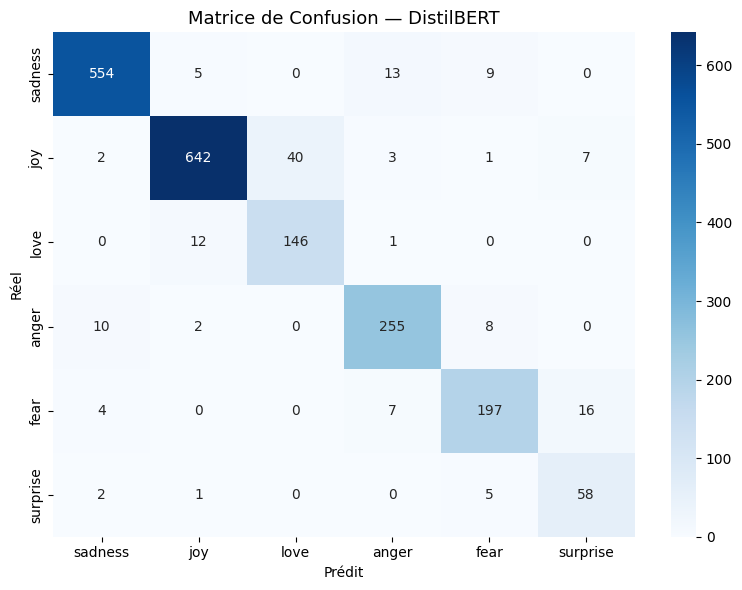

In [11]:
# Charger le meilleur modèle
model.load_state_dict(torch.load('best_distilbert.pt',
                                  map_location=device))
model.eval()

# Évaluation sur le test set
test_loss, test_acc, y_pred, y_true = evaluate(
    model, test_loader, loss_fn, device)

print(f"\n{'='*55}")
print(f"EVALUATION FINALE — DistilBERT")
print(f"{'='*55}")
print(f"✅ Test Loss     : {test_loss:.4f}")
print(f"✅ Test Accuracy : {test_acc*100:.2f}%")

# Classification Report
print("\nClassification Report :")
print(classification_report(y_true, y_pred,
                             target_names=emotion_names))

# Matrice de Confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)
plt.title('Matrice de Confusion — DistilBERT', fontsize=13)
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

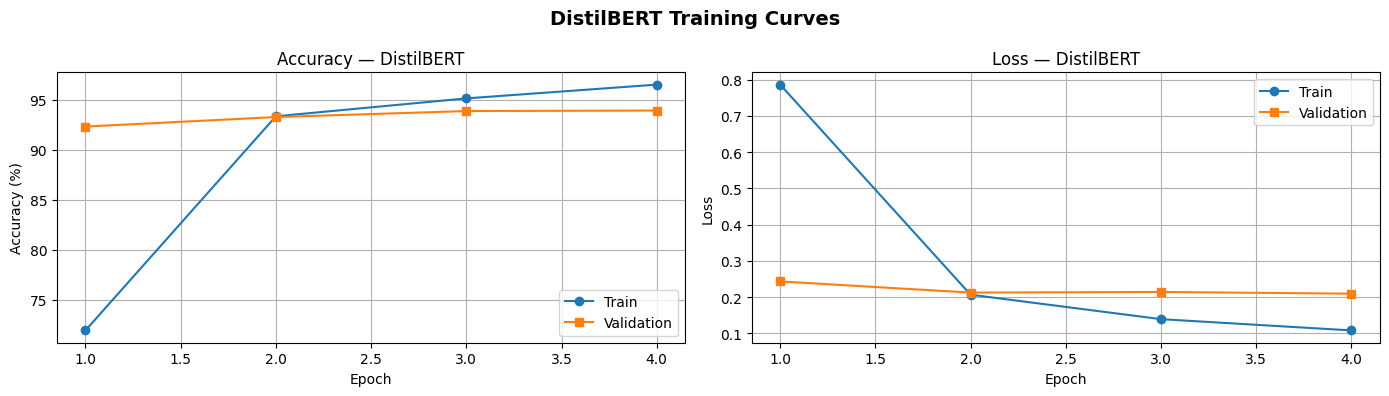

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(range(1, EPOCHS+1), [a*100 for a in history['train_acc']],
             marker='o', label='Train')
axes[0].plot(range(1, EPOCHS+1), [a*100 for a in history['val_acc']],
             marker='s', label='Validation')
axes[0].set_title('Accuracy — DistilBERT')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(range(1, EPOCHS+1), history['train_loss'],
             marker='o', label='Train')
axes[1].plot(range(1, EPOCHS+1), history['val_loss'],
             marker='s', label='Validation')
axes[1].set_title('Loss — DistilBERT')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('DistilBERT Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

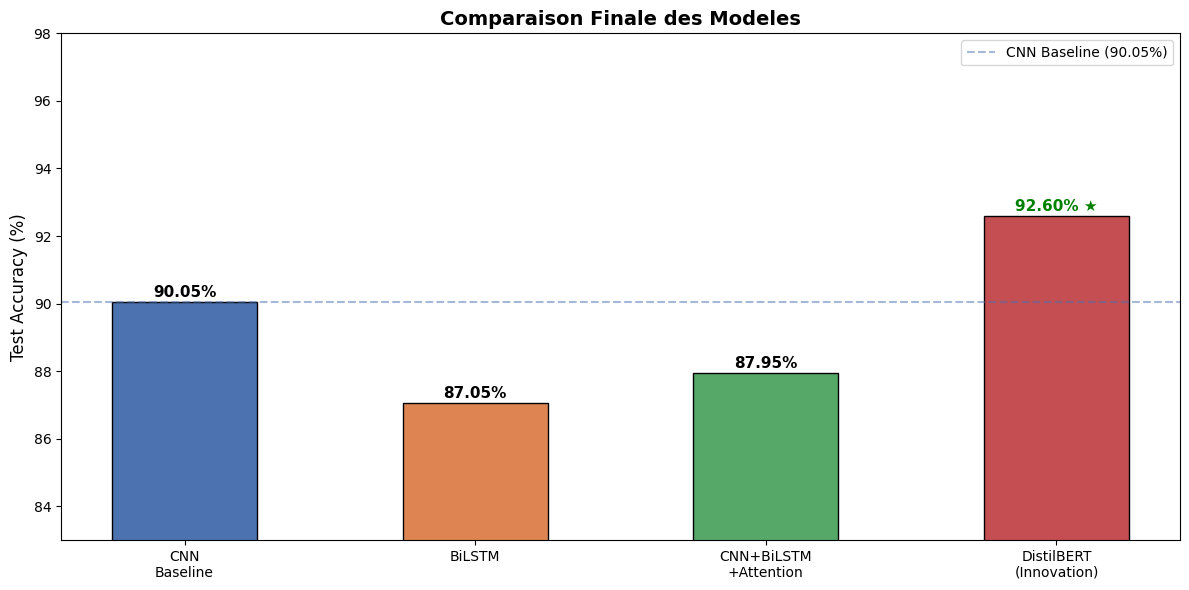


RESULTATS FINAUX
CNN Baseline           : 90.05%
BiLSTM                 : 87.05%
CNN+BiLSTM+Attention   : 87.95%
DistilBERT             : 92.60%  <- Innovation finale
Gain vs CNN Baseline   : +2.55%


In [13]:
acc_distilbert = test_acc * 100

models_names    = ['CNN\nBaseline', 'BiLSTM',
                   'CNN+BiLSTM\n+Attention',
                   'DistilBERT\n(Innovation)']
test_accuracies = [90.05, 87.05, 87.95, acc_distilbert]
colors          = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.figure(figsize=(12, 6))
bars = plt.bar(models_names, test_accuracies,
               color=colors, width=0.5, edgecolor='black')
plt.ylim(83, 98)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Comparaison Finale des Modeles', fontsize=14, fontweight='bold')

for bar, val in zip(bars, test_accuracies):
    is_best = val == max(test_accuracies)
    color   = 'green' if is_best else 'black'
    label   = f'{val:.2f}% ★' if is_best else f'{val:.2f}%'
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.15,
             label, ha='center',
             fontweight='bold', fontsize=11, color=color)

plt.axhline(y=90.05, color='#4C72B0', linestyle='--',
            alpha=0.5, label='CNN Baseline (90.05%)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n{'='*55}")
print("RESULTATS FINAUX")
print(f"{'='*55}")
print(f"CNN Baseline           : 90.05%")
print(f"BiLSTM                 : 87.05%")
print(f"CNN+BiLSTM+Attention   : 87.95%")
print(f"DistilBERT             : {acc_distilbert:.2f}%  <- Innovation finale")
gain = acc_distilbert - 90.05
sign = '+' if gain >= 0 else ''
print(f"Gain vs CNN Baseline   : {sign}{gain:.2f}%")

In [14]:
import os

# Créer le dossier
os.makedirs('emotion-api/model', exist_ok=True)

# Charger le meilleur modèle
model.load_state_dict(torch.load('best_distilbert.pt',
                                  map_location=device))

# Sauvegarder au format HuggingFace (recommandé)
model.save_pretrained('emotion-api/model')
tokenizer.save_pretrained('emotion-api/model')

print("✅ Modèle sauvegardé dans emotion-api/model/")
print(f"Fichiers : {os.listdir('emotion-api/model')}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle sauvegardé dans emotion-api/model/
Fichiers : ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [15]:
import os

os.makedirs('emotion-api/model', exist_ok=True)

model.save_pretrained('emotion-api/model')
tokenizer.save_pretrained('emotion-api/model')

print("✅ Model saved correctly")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved correctly
